In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from plotnine import ggplot, aes, geom_point, stat_smooth, labs
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
from imblearn.over_sampling import SMOTE

In [3]:
data = pd.read_csv("./dataset/diabetes.csv")

In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
data["Insulin"] = data["Insulin"].replace(0,np.nan)

In [6]:
data["Insulin"] = data["Insulin"].fillna(data["Insulin"].median())

In [7]:
data = data.sort_values(by='Insulin', ascending=True)

In [8]:
x = data[["Insulin"]]
y = data["Outcome"]

In [9]:
data = data[["Insulin","Outcome"]]

In [10]:
data["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = .2,random_state = 42)

In [12]:
test_df = pd.DataFrame(y_test,columns = ["Outcome"])
test_df = pd.concat([x_test,test_df],axis = 1)
test_df

,Insulin,Outcome
223,190.0,0
324,125.0,0
374,158.0,0
511,210.0,0
675,125.0,1
...,...,...
2,125.0,1
65,125.0,0
49,125.0,0
183,125.0,0


In [13]:
smote = SMOTE(random_state=42)
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)

In [14]:
model = LogisticRegression(max_iter=10000)
model.fit(x_sampled,y_sampled)

LogisticRegression(max_iter=10000)

In [15]:
ypred = model.predict(x_test)

In [18]:
ypred

array([1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

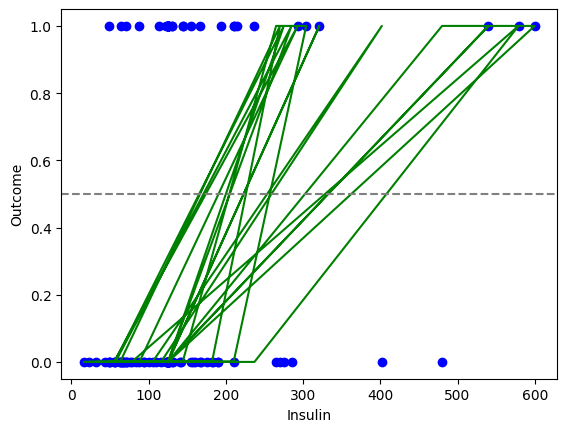

In [133]:
plt.scatter(x_test,y_test,color = "Blue")
plt.plot(x_test,ypred,color = "Green")
plt.axhline(0.5, color='gray', linestyle='--', label="Threshold = 0.5")
plt.xlabel("Insulin")
plt.ylabel("Outcome")
plt.show()

In [16]:
plot = (ggplot(test_df, aes(x='Insulin', y='Outcome')) +
    geom_point(color='blue', alpha=0.5, size=1.5) +
    stat_smooth(
        method='glm',
        method_args={'family': 'binomial'},
        se=False,
        color='Green',
        size=1.5
    ) +
    labs(title='Logistic Regression Curve', x='Isulin', y='Outcome') 
       )

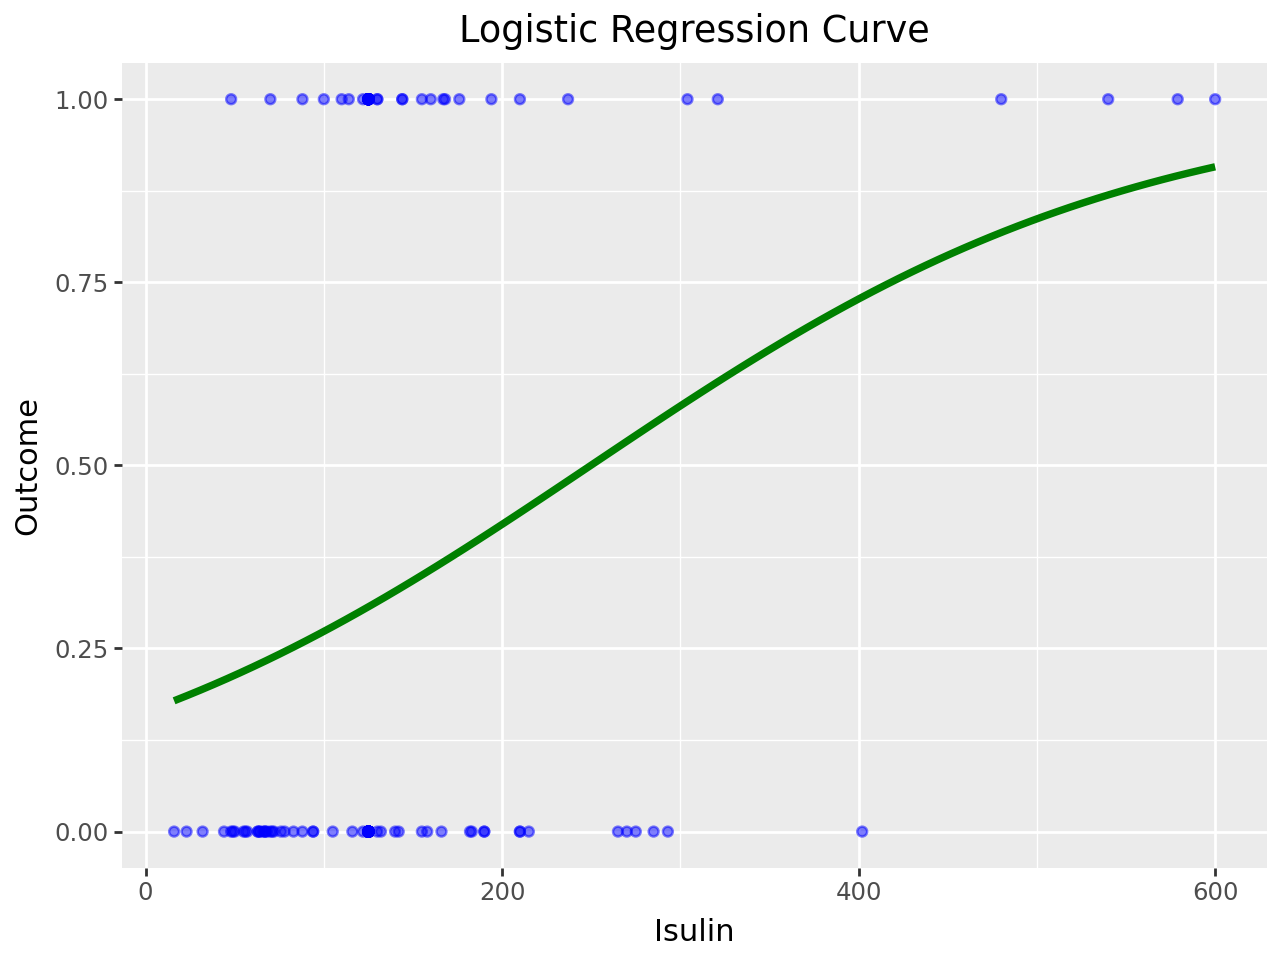

In [17]:
plot

In [19]:
pred = pd.DataFrame(ypred)
pred["Insulin"]= test_df["Insulin"]

In [22]:
test_df["Insulin"]

223    190.0
324    125.0
374    158.0
511    210.0
675    125.0
       ...  
2      125.0
65     125.0
49     125.0
183    125.0
464    125.0
Name: Insulin, Length: 154, dtype: float64

In [20]:
pred["Insulin"]= pred["Insulin"].astype("int64")

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
pred.info()

In [22]:
pred.rename(columns={0: 'Outcome'}, inplace=True)

In [23]:
plot1 = (ggplot(pred, aes(x='Insulin', y='Outcome')) +
    geom_point(color='Black', alpha=0.5, size=1.5) +
    stat_smooth(
        method='glm',
        method_args={'family': 'binomial'},
        se=False,
        color='Red',
        size=1.5
    ) +
    labs(title='Logistic Regression Curve', x='Isulin', y='Outcome') 
       )

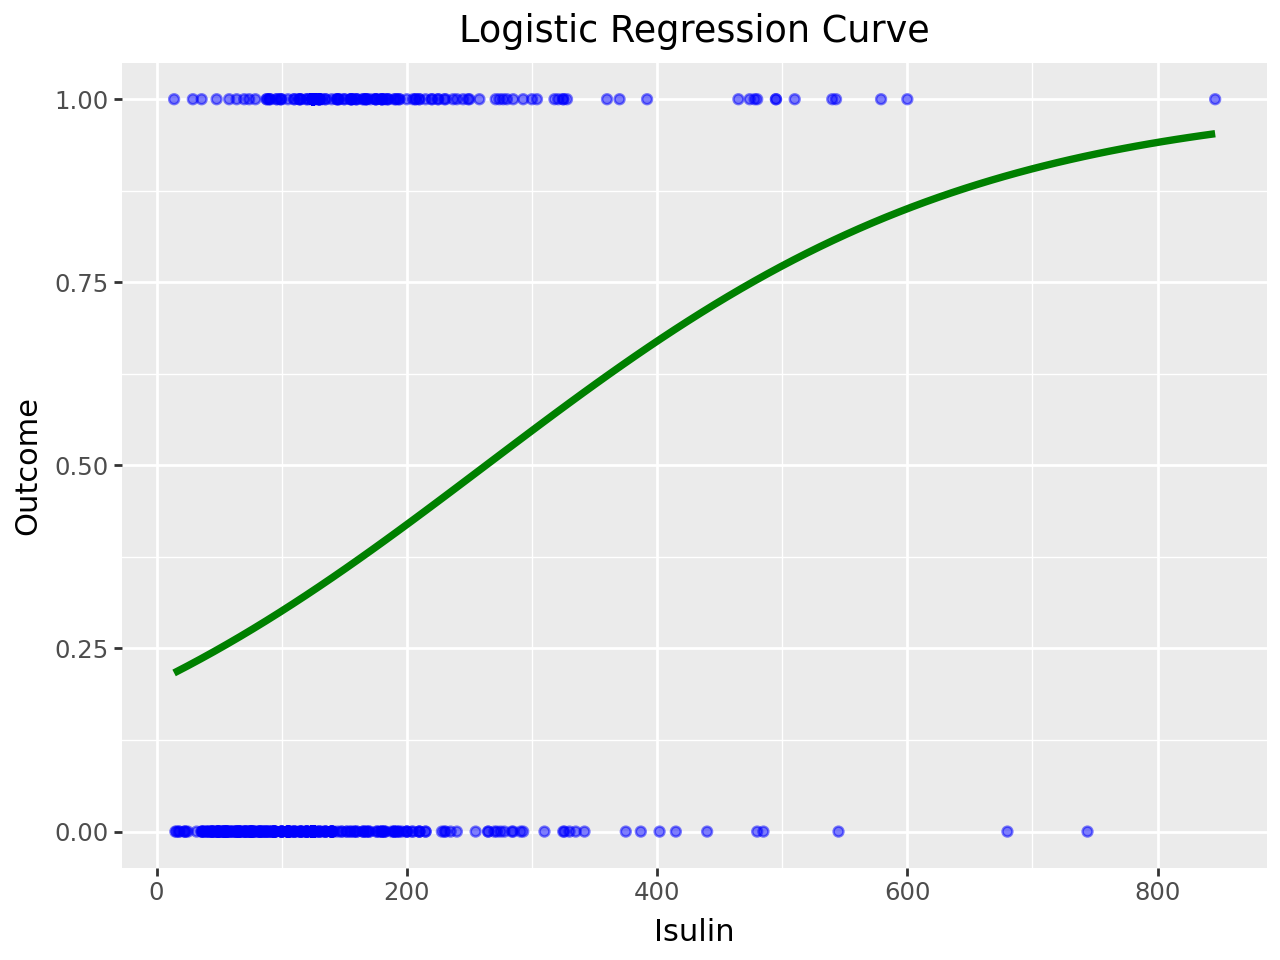

In [24]:
plot

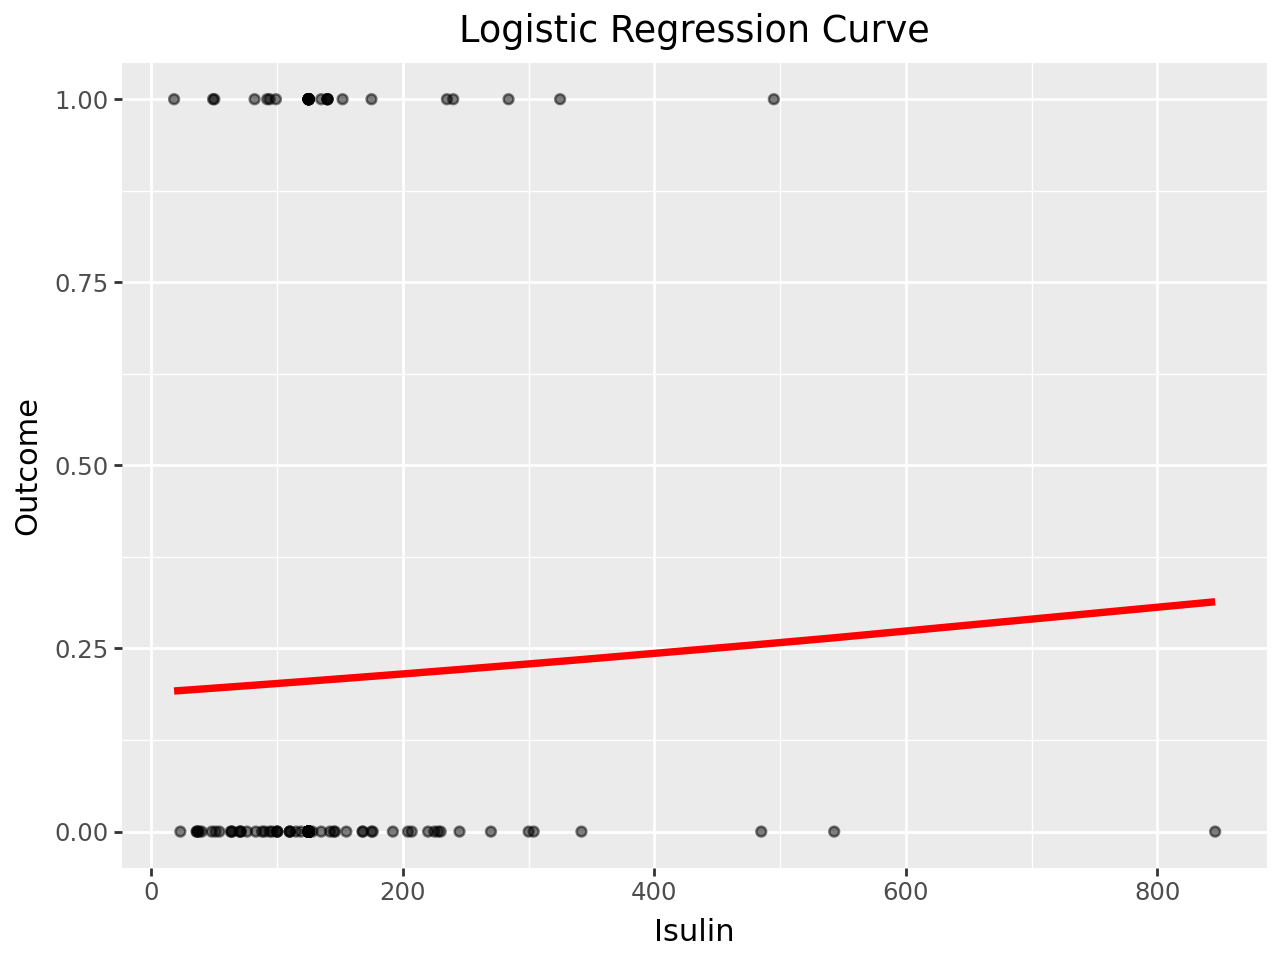

In [25]:
plot1

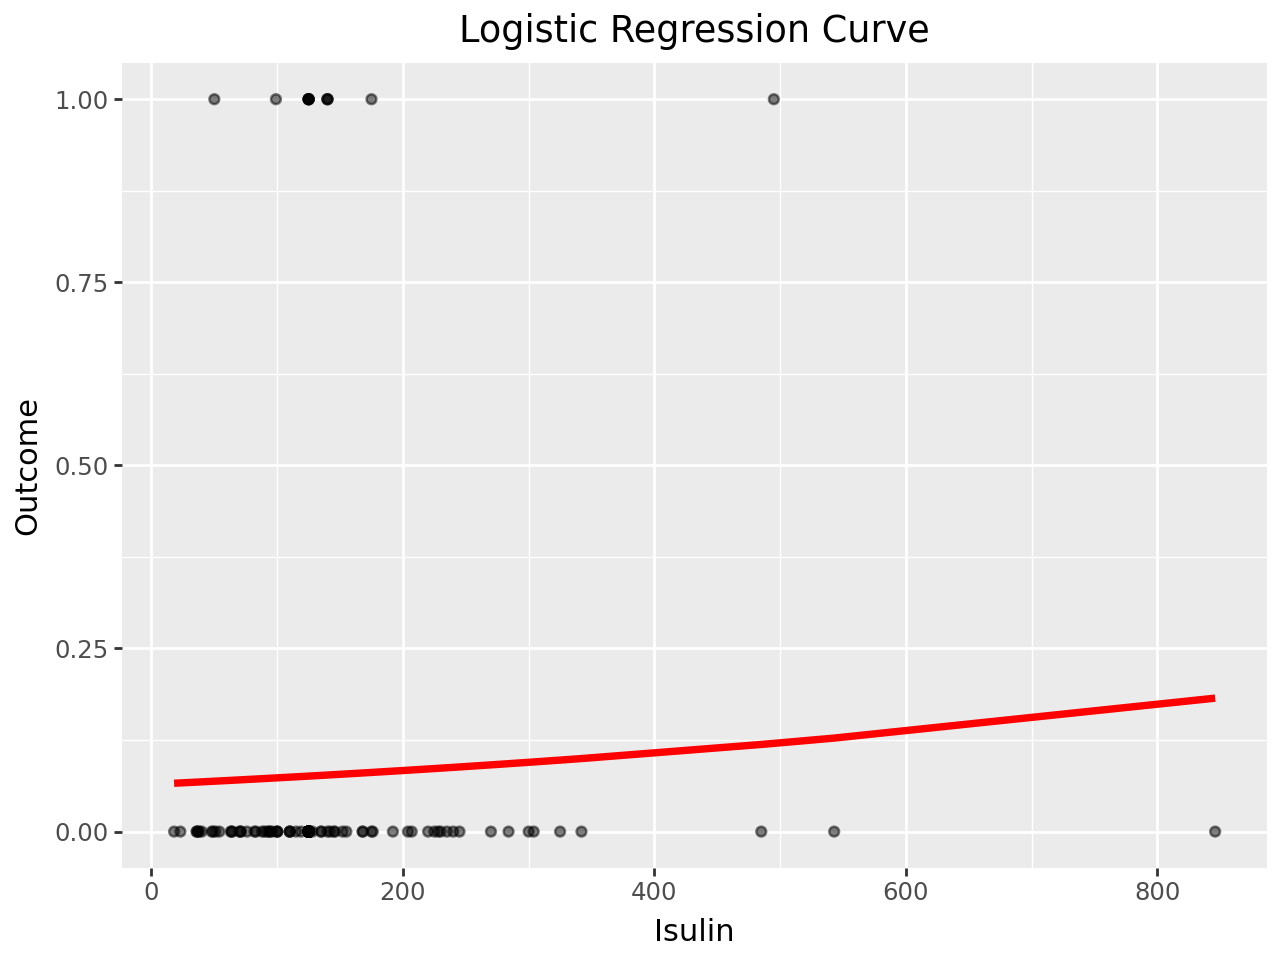

In [158]:
plot1

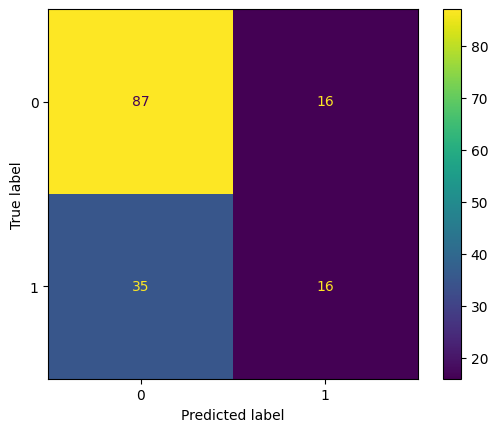

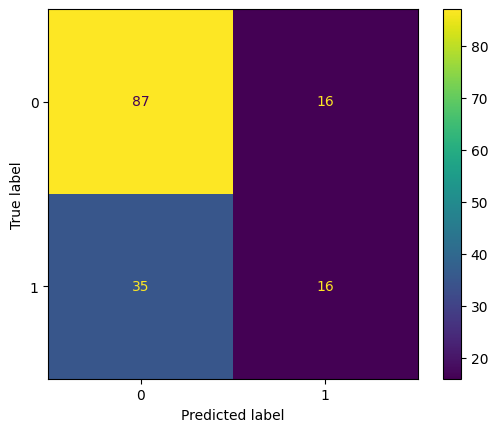

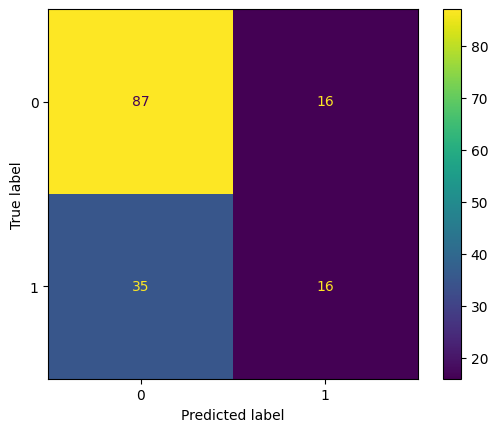

In [36]:
cm = confusion_matrix(y_test, ypred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()